In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/Readme.txt
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_15.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_8.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_6.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_11.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_4.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_14.tif
/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset/2_CLOUDY_DATASET/1_SENTINEL1/IMAGE_16_GRID/RASTER_13.tif
/kaggle/input/datasets/akhilchib

In [2]:
import os
try:
    import rasterio
except ImportError:
    !pip install rasterio -q
    import rasterio
import numpy as np

base = "/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset"

# read the two Readme files
for r in ["1_CLOUD_FREE_DATASET/Readme.txt", "3_TRAINING_MASKS/Readme.txt"]:
    print("=====", r)
    print(open(f"{base}/{r}").read()[:1500])

# look at one image and its mask
img_path  = f"{base}/1_CLOUD_FREE_DATASET/2_SENTINEL2/IMAGE_16_GRID/RASTER_0.tif"
mask_path = f"{base}/3_TRAINING_MASKS/MASK_16_GRID/RASTER_0.tif"

with rasterio.open(img_path) as f:
    img = f.read()
    print("IMAGE shape (bands, height, width):", img.shape, "dtype:", img.dtype)
    print("min/max:", img.min(), img.max())

with rasterio.open(mask_path) as f:
    m = f.read()
    print("MASK shape:", m.shape, "dtype:", m.dtype)
    print("mask values and counts:", np.unique(m, return_counts=True))

===== 1_CLOUD_FREE_DATASET/Readme.txt
Title of the dataset:
CLOUD FREE DATASET FOR PERFORMING SEMANTIC SEGMENTATION FOR DEFORESTATION MAPPING USING DEEP LEARNING BASED LATE FUSION ARCHITECTURE


Creators:
AKHIL CHHIBBER


Contributors:
1. RAIAN VARGAS MARETTE
2. MARIANA BELGIU
3. SUGANDH CHAUHAN


Description:
This folder includes a total of two sub folders titled (i) 1_SENTINEL1 and (ii) 2_SENTINEL2. 


Keywords:
SENTINEL1, SENTINEL2, CLOUD FREE


This dataset contains the following folders:
1. 1_SENTINEL1 
2. 2_SENTINEL2


Explanation of variables:
1. Firstly, the "1_SENTINEL1" folder includes the Sentinel-1 dataset dated 22nd July 2020. This dataset is further sub-divided into two seperate folders, (i) IMAGE_FULL which includes the complete raster of the study area and (ii) IMAGE_16_GRID which includes 16 patches which covers the study area.
2. Secondly, the "2_SENTINEL2" folder includes the Sentinel-2 dataset dated 27th July 2020. This dataset is further sub-divided into two sepera

patch | % class1 | % class2
    0 |      3.2 |     96.8
    1 |      2.9 |     97.1
    2 |     11.2 |     88.8
    3 |     21.0 |     79.0
    4 |     13.3 |     86.7
    5 |     30.4 |     69.6
    6 |     58.7 |     41.3
    7 |     78.4 |     21.6
    8 |     16.9 |     83.1
    9 |     57.5 |     42.5
   10 |     57.8 |     42.2
   11 |     49.6 |     50.4
   12 |     53.1 |     46.9
   13 |     56.6 |     43.4
   14 |     67.8 |     32.2
   15 |     42.7 |     57.3
band means (1,2,3,4): [162.0, 369.9, 191.7, 2972.5]


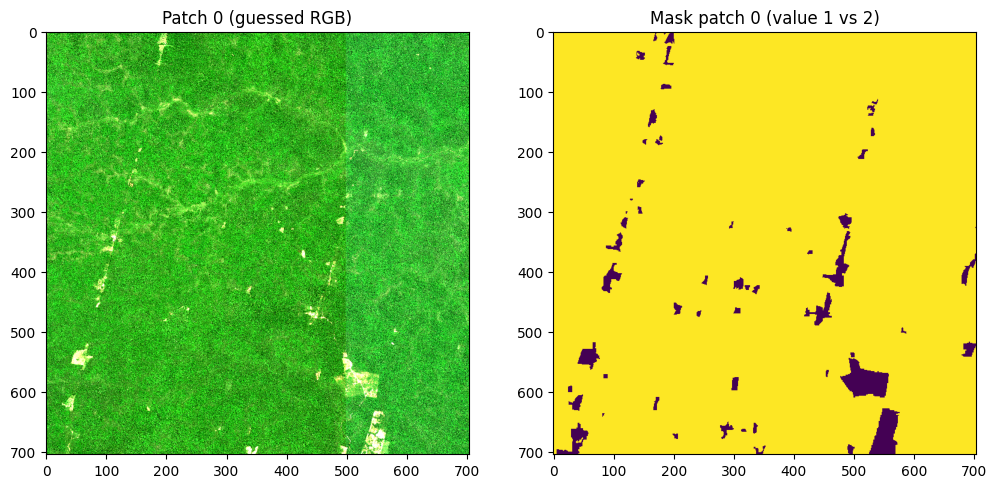

In [3]:
import numpy as np, rasterio
import matplotlib.pyplot as plt

base = "/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset"

# 1) How much of each patch is class 1 vs class 2?
print("patch | % class1 | % class2")
for i in range(16):
    with rasterio.open(f"{base}/3_TRAINING_MASKS/MASK_16_GRID/RASTER_{i}.tif") as f:
        m = f.read(1, out_shape=(704, 704))   # shrunk 4x, fast
    print(f"{i:>5} | {100*(m==1).mean():8.1f} | {100*(m==2).mean():8.1f}")

# 2) Look at patch 0: image (assuming bands = B,G,R,NIR) next to its mask
img_p  = f"{base}/1_CLOUD_FREE_DATASET/2_SENTINEL2/IMAGE_16_GRID/RASTER_0.tif"
mask_p = f"{base}/3_TRAINING_MASKS/MASK_16_GRID/RASTER_0.tif"
with rasterio.open(img_p) as f:
    img = f.read(out_shape=(4, 704, 704))
with rasterio.open(mask_p) as f:
    msk = f.read(1, out_shape=(704, 704))

print("band means (1,2,3,4):", [round(float(img[b].mean()), 1) for b in range(4)])

rgb = img[[2, 1, 0]].transpose(1, 2, 0)           # bands 3,2,1 as R,G,B
lo, hi = np.percentile(rgb, (2, 98))
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(rgb);  ax[0].set_title("Patch 0 (guessed RGB)")
ax[1].imshow(msk);  ax[1].set_title("Mask patch 0 (value 1 vs 2)")
plt.show()

In [4]:
import numpy as np
import rasterio
import gc  # <--- Import garbage collector to force clear RAM

base = "/kaggle/input/datasets/akhilchibber/deforestation-detection-dataset"

T = 128            # tile size in pixels (2816 / 128 = 22 tiles per side)
LO, HI = 0, 800    # fixed brightness range for R,G,B (same for every tile)
DEF_MIN = 0.10     # >=10% class 1  -> deforested
FOREST_MAX = 0.01  # <=1%  class 1  -> forest

X, y, pid = [], [], []
for i in range(16):
    with rasterio.open(f"{base}/1_CLOUD_FREE_DATASET/2_SENTINEL2/IMAGE_16_GRID/RASTER_{i}.tif") as f:
        img = f.read()                       # (4, 2816, 2816)
    with rasterio.open(f"{base}/3_TRAINING_MASKS/MASK_16_GRID/RASTER_{i}.tif") as f:
        m = f.read(1)

    rgb = np.clip((img[[2, 1, 0]] - LO) / (HI - LO), 0, 1)
    rgb = (rgb * 255).astype(np.uint8).transpose(1, 2, 0)   # (H, W, 3)
    defo = (m == 1)

    n = 2816 // T
    for r in range(n):
        for c in range(n):
            sl = (slice(r*T, (r+1)*T), slice(c*T, (c+1)*T))
            frac = defo[sl].mean()
            if frac >= DEF_MIN:      lab = 1
            elif frac <= FOREST_MAX: lab = 0
            else: continue
            
            # CRITICAL FIX: Adding .copy() breaks the memory pointer reference 
            # to the giant parent array, allowing the parent array to be safely deleted later.
            X.append(rgb[sl].copy()) 
            y.append(lab)
            pid.append(i)
            
    print("patch", i, "done | tiles so far:", len(y))
    
    # CRITICAL FIX: Force wipe the massive parent arrays at the end of every loop iteration
    del img, m, rgb, defo
    gc.collect()

X, y, pid = np.array(X), np.array(y), np.array(pid)
np.savez_compressed("/kaggle/working/tiles.npz", X=X, y=y, pid=pid)

print("total tiles:", len(y), "| deforested:", y.sum(), "| forest:", (y == 0).sum())
for i in range(16):
    s = pid == i
    print(f"patch {i:>2}: {s.sum():>4} tiles, {y[s].sum():>4} deforested")


patch 0 done | tiles so far: 437
patch 1 done | tiles so far: 887
patch 2 done | tiles so far: 1312
patch 3 done | tiles so far: 1664
patch 4 done | tiles so far: 2067
patch 5 done | tiles so far: 2488
patch 6 done | tiles so far: 2940
patch 7 done | tiles so far: 3414
patch 8 done | tiles so far: 3834
patch 9 done | tiles so far: 4290
patch 10 done | tiles so far: 4743
patch 11 done | tiles so far: 5194
patch 12 done | tiles so far: 5650
patch 13 done | tiles so far: 6109
patch 14 done | tiles so far: 6572
patch 15 done | tiles so far: 7027
total tiles: 7027 | deforested: 4465 | forest: 2562
patch  0:  437 tiles,   46 deforested
patch  1:  450 tiles,   34 deforested
patch  2:  425 tiles,  120 deforested
patch  3:  352 tiles,  206 deforested
patch  4:  403 tiles,  153 deforested
patch  5:  421 tiles,  286 deforested
patch  6:  452 tiles,  410 deforested
patch  7:  474 tiles,  451 deforested
patch  8:  420 tiles,  183 deforested
patch  9:  456 tiles,  404 deforested
patch 10:  453 tiles

In [5]:
import numpy as np, torch, torchvision
from torchvision import transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, f1_score

d = np.load("/kaggle/working/tiles.npz")
X, y, pid = d["X"], d["y"], d["pid"]

TEST_PATCHES = [1, 4, 11, 14]
test = np.isin(pid, TEST_PATCHES)

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev)
net = torchvision.models.resnet50(weights="IMAGENET1K_V2")
net.fc = torch.nn.Identity()
net = net.eval().to(dev)
prep = transforms.Compose([
    transforms.Resize(224),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

feats = []
with torch.no_grad():
    for i in range(0, len(X), 128):
        b = torch.from_numpy(X[i:i+128]).permute(0, 3, 1, 2).float().div(255).to(dev)
        feats.append(net(prep(b)).cpu().numpy())
F = np.concatenate(feats)
np.savez_compressed("/kaggle/working/resnet_feats.npz", F=F, y=y, pid=pid, test=test)
print("features:", F.shape)

Fp, yp, gp = F[~test], y[~test], pid[~test]
bal, f1s = [], []
for tr, va in GroupKFold(n_splits=4).split(Fp, yp, gp):
    rf = RandomForestClassifier(300, class_weight="balanced", random_state=0, n_jobs=-1)
    rf.fit(Fp[tr], yp[tr])
    p = rf.predict(Fp[va])
    bal.append(balanced_accuracy_score(yp[va], p)); f1s.append(f1_score(yp[va], p))
    print(f"fold val patches {sorted(set(gp[va]))}: bal-acc {bal[-1]:.3f}, F1 {f1s[-1]:.3f}")
print(f"CV balanced acc {np.mean(bal):.3f} ± {np.std(bal):.3f}")

device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


features: (7027, 2048)
fold val patches [np.int64(0), np.int64(5), np.int64(7)]: bal-acc 0.967, F1 0.971
fold val patches [np.int64(6), np.int64(8), np.int64(13)]: bal-acc 0.867, F1 0.950
fold val patches [np.int64(3), np.int64(9), np.int64(15)]: bal-acc 0.942, F1 0.957
fold val patches [np.int64(2), np.int64(10), np.int64(12)]: bal-acc 0.935, F1 0.956
CV balanced acc 0.928 ± 0.037
